# P02 — Calculus & the Chain Rule  *(the urge to get better)*

> **The story so far.** In [P01](P01_Linear_Algebra.ipynb) the mind grew its first sense — the dot
> product — and learned to fire a whole panel of them as a layer. It can now *feel* things, and even
> notice when it's wrong. But noticing isn't improving. A thermostat that merely knew "the room is
> too cold" but couldn't tell *which way to nudge the dial* would be useless. Today we give the mind
> the one thing that turns sensing into learning: the **urge to get better** — a slope it can follow
> downhill. This is the heartbeat we will hear for the rest of the journey: **predict → measure how
> wrong → step downhill**. Master it on one tiny curve here, and you've understood how a billion-
> parameter model trains.

[P01](P01_Linear_Algebra.ipynb) gave us the operations a network *computes*. This notebook gives
the other half: how a network *learns* — by following **derivatives** downhill. The whole of
training is "compute how wrong we are (a number called loss), find the slope of that wrongness
with respect to each weight, and step the opposite way." Those slopes are derivatives; the rule
for chaining them through many layers is the **chain rule**, and that rule *is* backpropagation.

We keep functions tiny and check **every** hand-derivative two ways: with calculus, and
**numerically** (nudge the input a hair and measure the change). When both agree, you can trust it.

## B1 — The derivative is just a slope: "if I nudge x, how much does f move?"

Stand on a hillside in thick fog. You can't see the summit or the valley, but you *can* feel the
ground under one foot: tilted up to the left, down to the right, and *how steeply*. That local tilt
is all you need to know which way to step. The mind learns the same way — it never sees the whole
loss landscape, only the slope right where it's standing. That slope is the **derivative**.

The **derivative** `f'(x)` answers one question: *if I increase x by a tiny amount, how fast does
f(x) change, and in which direction?* It is the slope of the curve at that point.

**Numerical definition (how we'll always sanity-check):**
```
f'(x) ≈ ( f(x + h) − f(x − h) ) / (2h)        for a tiny h, e.g. 0.0001
```
This is literally "rise over run" measured across a tiny step around x.

**Worked example by hand.** For `f(x) = x²`, calculus gives `f'(x) = 2x`. At `x = 3`:
```
f'(3) = 2 × 3 = 6
```
Check numerically with `h = 0.001`:
```
f(3.001) = 9.006001
f(2.999) = 8.994001
slope ≈ (9.006001 − 8.994001) / 0.002 = 0.012 / 0.002 = 6.0   ✓ matches
```

In [1]:
import numpy as np

def f(x):  return x**2
def fp(x): return 2*x                      # hand-derived derivative

def numeric_deriv(fn, x, h=1e-4):
    return (fn(x + h) - fn(x - h)) / (2*h) # central difference

x = 3.0
print("hand f'(3)      =", fp(x), " (= 2*3)")
print("numeric f'(3)   =", round(numeric_deriv(f, x), 6), " <- matches the hand answer")
print("\nslope at several points (notice it changes — the curve bends):")
for x in [-2, -1, 0, 1, 2]:
    print(f"  x={x:>3}: hand 2x={2*x:>3}, numeric={numeric_deriv(f, x):>6.3f}")

hand f'(3)      = 6.0  (= 2*3)
numeric f'(3)   = 6.0  <- matches the hand answer

slope at several points (notice it changes — the curve bends):
  x= -2: hand 2x= -4, numeric=-4.000
  x= -1: hand 2x= -2, numeric=-2.000
  x=  0: hand 2x=  0, numeric= 0.000
  x=  1: hand 2x=  2, numeric= 2.000
  x=  2: hand 2x=  4, numeric= 4.000


### 📊 Step 4 — See it & play with it: the derivative *is* the slope of the tangent line

The picture shows the curve `f(x)=x²` and the **tangent line** touching it at your chosen point. The
slope of that line *is* `f'(x)=2x`. Notice the tangent tilts as you move along the curve — flat at
`x=0` (slope 0), steepening as `|x|` grows. That "how tilted is the curve right here" is the entire
meaning of a derivative.

**▶ Run the cell and drag `x`:** read the slope in the title and watch the tangent line tilt. Find
where the slope is 0 (the bottom), positive (right side), and negative (left side).

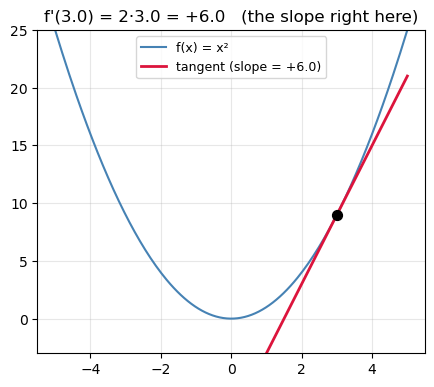

interactive(children=(FloatSlider(value=3.0, description='x', max=4.0, min=-4.0, step=0.25), Output()), _dom_c…

In [2]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_tangent(x=3.0):
    f  = lambda t: t**2
    fp = lambda t: 2*t                                      # the derivative
    xs = np.linspace(-5, 5, 200)
    slope = fp(x)
    tangent = f(x) + slope*(xs - x)                         # line through (x,f(x)) with slope f'(x)
    fig, ax = plt.subplots(figsize=(5, 4.2))
    ax.plot(xs, f(xs), color="steelblue", label="f(x) = x²")
    ax.plot(xs, tangent, color="crimson", lw=2, label=f"tangent (slope = {slope:+.1f})")
    ax.scatter([x], [f(x)], color="black", zorder=3, s=50)
    ax.set_ylim(-3, 25); ax.grid(alpha=.3); ax.legend(loc="upper center", fontsize=9)
    ax.set_title(f"f'({x:.1f}) = 2·{x:.1f} = {slope:+.1f}   (the slope right here)")
    plt.show()

show_tangent()                                              # static picture (always visible)
interact(show_tangent,                                      # ▶ live slider (drag it in your IDE)
         x=FloatSlider(min=-4, max=4, step=0.25, value=3.0, description="x"));

## B2 — The three derivative rules we ever need

You don't carry a tape measure to know that a steeper ramp is harder to climb — you pick up a few
quick rules of thumb and read slopes by eye. The mind needs the same small toolkit: not a semester
of calculus, just three rules that let it find the slope of almost any expression it will ever meet.

You do not need a calculus course. Three rules cover almost everything in this playbook:

| Function `f(x)` | Derivative `f'(x)` | In words |
|-----------------|--------------------|----------|
| `x^n` (power) | `n · x^(n-1)` | bring the power down, subtract one |
| `c · g(x)` (constant times) | `c · g'(x)` | constants pass straight through |
| `g(x) + h(x)` (sum) | `g'(x) + h'(x)` | derivative of a sum is the sum of derivatives |

**Worked example by hand.** `f(x) = 3x² + 2x + 5`:
```
d/dx[3x²] = 3·2x = 6x
d/dx[2x ] = 2
d/dx[5  ] = 0          (a constant has zero slope — flat)
f'(x) = 6x + 2
```
At `x = 1`: `f'(1) = 6 + 2 = 8`.

In [3]:
import numpy as np
def f(x):  return 3*x**2 + 2*x + 5
def fp(x): return 6*x + 2
def numeric_deriv(fn, x, h=1e-4): return (fn(x+h) - fn(x-h)) / (2*h)

print("hand    f'(1) =", fp(1.0), " (6*1 + 2)")
print("numeric f'(1) =", round(numeric_deriv(f, 1.0), 5))
print("hand    f'(0) =", fp(0.0), " (the +5 constant contributes nothing)")
print("numeric f'(0) =", round(numeric_deriv(f, 0.0), 5))

hand    f'(1) = 8.0  (6*1 + 2)
numeric f'(1) = 8.0
hand    f'(0) = 2.0  (the +5 constant contributes nothing)
numeric f'(0) = 2.0


## B3 — The chain rule: the heart of backpropagation

Think of a row of gears. Turn the first one a little and the second turns by *its* gear ratio, which
spins the third by *its* ratio. To know how much the last gear moves when you nudge the first, you
**multiply the ratios down the line**. A network is exactly this train of gears: a weight turns a
hidden value, which turns the output, which turns the loss. Multiplying the local slopes along that
chain — the **chain rule** — is how the mind traces a tiny nudge deep inside back out to the loss.

Networks are **functions inside functions**: a loss depends on an output, which depends on a
hidden layer, which depends on a weight. To get "how does the loss change if I nudge this *early*
weight?" we multiply the slopes along the chain. That multiplication is the **chain rule**, and it
is exactly how gradients travel *backward* through a network.

**Rule:** if `y = f(g(x))`, write `u = g(x)`. Then
```
dy/dx = (dy/du) × (du/dx)        "outer slope times inner slope"
```

**Worked example by hand.** `y = (3x + 1)²`. Let `u = 3x + 1`, so `y = u²`.
```
dy/du = 2u = 2(3x + 1)
du/dx = 3
dy/dx = 2(3x + 1) × 3 = 6(3x + 1)
```
At `x = 2`:  `u = 7`,  `dy/dx = 6 × 7 = 42`.

This "multiply the local slopes along the path" is *the whole idea* of backprop. P11 applies it to
a real network; here we just trust it on one tiny composed function.

In [4]:
import numpy as np
def y(x):  return (3*x + 1)**2
def yp(x): return 6*(3*x + 1)              # via chain rule, by hand
def numeric_deriv(fn, x, h=1e-4): return (fn(x+h) - fn(x-h)) / (2*h)

x = 2.0
print("inner u = 3x+1  =", 3*x + 1)
print("hand    dy/dx   =", yp(x), " (= 6*(3x+1) = 6*7)")
print("numeric dy/dx   =", round(numeric_deriv(y, x), 4), " <- confirms the chain rule")

inner u = 3x+1  = 7.0
hand    dy/dx   = 42.0  (= 6*(3x+1) = 6*7)
numeric dy/dx   = 42.0  <- confirms the chain rule


## B4 — Partial derivatives & the gradient: slope in many directions at once

A hiker on a real mountainside doesn't face just "uphill" — the ground slopes one way north-south
and another east-west. Ask "if I step purely north, how steep is it?" (freezing east-west) and you
get one *partial* slope; ask the same going east and you get another. Bundle those directional
slopes together and you get an arrow pointing straight up the steepest part of the slope — the
**gradient**. The mind faces a million directions at once (one per weight), but the idea is identical.

A loss depends on *many* weights, not one. A **partial derivative** `∂f/∂x` is the slope in the
`x` direction while holding all other variables fixed. Stack all the partials into a vector and you
get the **gradient** `∇f` — it points in the direction of *steepest increase*, so to *decrease* the
loss we step in the **opposite** direction (that's gradient descent, B5).

**Worked example by hand.** `f(x, y) = x² + 3xy`.
```
∂f/∂x : treat y as a constant  ->  2x + 3y
∂f/∂y : treat x as a constant  ->  0  + 3x = 3x
gradient ∇f = [ 2x + 3y , 3x ]
```
At `(x, y) = (1, 2)`:
```
∂f/∂x = 2(1) + 3(2) = 8
∂f/∂y = 3(1)        = 3
∇f = [8, 3]
```

In [5]:
import numpy as np
def f(x, y):  return x**2 + 3*x*y
def grad(x, y): return np.array([2*x + 3*y, 3*x])      # hand-derived partials

def numeric_grad(fn, x, y, h=1e-4):
    dfdx = (fn(x+h, y) - fn(x-h, y)) / (2*h)           # nudge only x
    dfdy = (fn(x, y+h) - fn(x, y-h)) / (2*h)           # nudge only y
    return np.array([dfdx, dfdy])

x, y = 1.0, 2.0
print("hand    grad at (1,2) =", grad(x, y), " (= [8, 3])")
print("numeric grad at (1,2) =", np.round(numeric_grad(f, x, y), 4))
print("\nthe gradient points UPHILL; gradient descent steps the OPPOSITE way to reduce f.")

hand    grad at (1,2) = [8. 3.]  (= [8, 3])
numeric grad at (1,2) = [8. 3.]

the gradient points UPHILL; gradient descent steps the OPPOSITE way to reduce f.


## B5 — Gradient descent: walking downhill using the slope

Back on the foggy hillside from B1 — now you finally *act*. Feel which way is downhill, take a step
that size, feel again, step again. Do it enough and you reach the valley floor without ever seeing
it. That patient, blind, slope-following walk is **gradient descent**, and it is how every model in
this playbook — up to and including the GPT — actually learns. The mind has found its urge to improve.

Now we use derivatives to *learn*. The rule from Notebook 00, B12, stated precisely:
```
new_w = old_w − learning_rate × gradient
```
We step opposite the slope (downhill), by an amount controlled by the **learning rate**.

**Worked example by hand.** Minimise `L(w) = (w − 3)²` (best is obviously `w = 3`). Slope
`L'(w) = 2(w − 3)`. Start `w = 0`, learning rate `0.1`:
```
step 1: w=0.00  grad=2(0−3)=−6.0   w ← 0.00 − 0.1·(−6.0) = 0.60
step 2: w=0.60  grad=2(0.6−3)=−4.8 w ← 0.60 − 0.1·(−4.8) = 1.08
step 3: w=1.08  grad=−3.84         w ← 1.08 + 0.384       = 1.46
```
Each step `w` crawls toward 3 and the loss shrinks. A real network does this for *millions* of
weights, with the gradients supplied by backprop (the chain rule, B3). The plot shows convergence.

In [6]:
import numpy as np
w, lr = 0.0, 0.1
print(f"{'step':>4} {'w':>8} {'loss':>8} {'grad':>8}")
for step in range(1, 16):
    loss = (w - 3)**2
    grad = 2*(w - 3)
    if step <= 5 or step % 5 == 0:
        print(f"{step:>4} {w:>8.3f} {loss:>8.3f} {grad:>8.3f}")
    w = w - lr*grad
print(f"\nafter 15 steps w = {w:.3f}  (true minimum is 3.000) — it learned the slope downhill")

step        w     loss     grad
   1    0.000    9.000   -6.000
   2    0.600    5.760   -4.800
   3    1.080    3.686   -3.840
   4    1.464    2.359   -3.072
   5    1.771    1.510   -2.458
  10    2.597    0.162   -0.805
  15    2.868    0.017   -0.264

after 15 steps w = 2.894  (true minimum is 3.000) — it learned the slope downhill


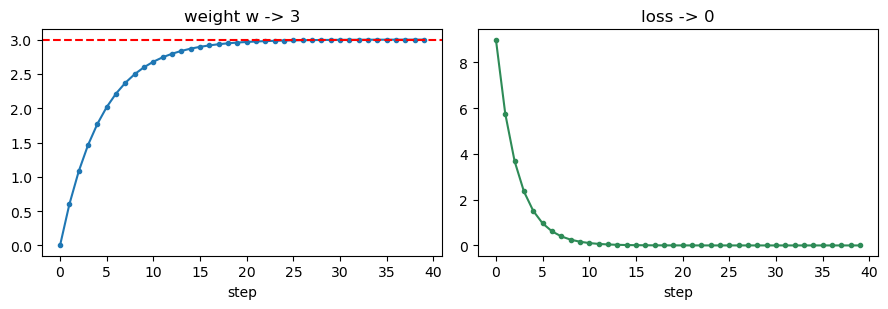

left: w approaches the dashed target 3.   right: loss approaches 0.


In [7]:
import numpy as np, matplotlib.pyplot as plt
ws, losses, w, lr = [], [], 0.0, 0.1
for _ in range(40):
    ws.append(w); losses.append((w-3)**2)
    w -= lr*2*(w-3)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(ws, marker="o", ms=3); a1.axhline(3, ls="--", c="r"); a1.set_title("weight w -> 3"); a1.set_xlabel("step")
a2.plot(losses, marker="o", ms=3, c="seagreen"); a2.set_title("loss -> 0"); a2.set_xlabel("step")
plt.tight_layout(); plt.show()
print("left: w approaches the dashed target 3.   right: loss approaches 0.")

### 📊 Step 4 — See it & play with it: roll the ball down the loss bowl

The blue curve is the loss `L(w)=(w−3)²`. Each red dot is one gradient-descent step, starting from
`w=0` — the ball rolling downhill toward the minimum at `w=3`. The **learning-rate** slider is the
key knob: too small and the ball barely moves (crawls), just right and it glides in, too big and it
**overshoots and bounces** — past about `lr=1` it diverges and flies *uphill*.

**▶ Run the cell and sweep the learning rate:**
1. `lr = 0.1` — smooth convergence to 3.
2. `lr = 0.01` — painfully slow (the dots barely advance).
3. `lr = 1.0` — it overshoots and oscillates; **`lr = 1.05`** — it explodes outward. *This single
   slider is why "learning rate too high" is the #1 training failure (P12).*

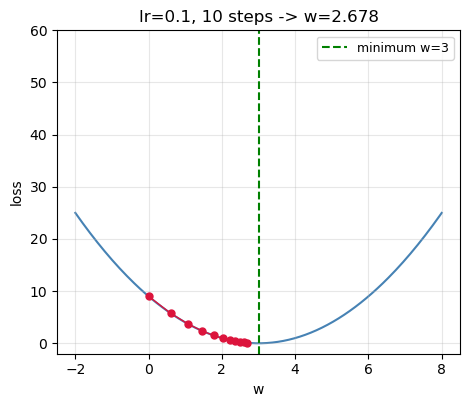

interactive(children=(FloatSlider(value=0.1, description='learning rate', max=1.1, min=0.01, step=0.01), IntSl…

In [8]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

def show_descent(lr=0.1, steps=10):
    L  = lambda w: (w - 3)**2
    dL = lambda w: 2*(w - 3)
    ws = np.linspace(-2, 8, 200)
    w, path = 0.0, [0.0]
    for _ in range(steps):
        w = w - lr*dL(w); path.append(w)
    path = np.array(path)
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.plot(ws, L(ws), color="steelblue", zorder=1)
    ax.plot(path, L(path), "o-", color="crimson", ms=5, lw=1, zorder=2)
    ax.axvline(3, ls="--", color="green", label="minimum w=3")
    diverged = abs(path[-1]) > 50
    ax.set_ylim(-2, 60); ax.grid(alpha=.3); ax.set_xlabel("w"); ax.set_ylabel("loss")
    end = "DIVERGED!" if diverged else f"w={path[-1]:.3f}"
    ax.set_title(f"lr={lr}, {steps} steps -> {end}", color=("red" if diverged else "black"))
    ax.legend(fontsize=9); plt.show()

show_descent()                                              # static picture (always visible)
interact(show_descent,                                      # ▶ live sliders (drag them in your IDE)
         lr=FloatSlider(min=0.01, max=1.1, step=0.01, value=0.1, description="learning rate"),
         steps=IntSlider(min=1, max=40, step=1, value=10, description="steps"));

## Recap — calculus, exactly as much as ML needs

| Idea | Formula | Why it matters |
|------|---------|----------------|
| Derivative | slope of `f` at `x` | how loss responds to a weight |
| Power rule | `d/dx xⁿ = n xⁿ⁻¹` | covers most layer math |
| Chain rule | `dy/dx = dy/du · du/dx` | **this is backpropagation** |
| Partial derivative | slope in one variable, others fixed | loss depends on many weights |
| Gradient `∇f` | vector of all partials | points uphill; step opposite to learn |
| Gradient descent | `w ← w − lr·grad` | the universal training rule |

## Common mistakes
1. **Sign errors in the step.** We *subtract* the gradient (go downhill). Adding it climbs uphill.
2. **Forgetting the chain rule's inner slope.** `d/dx (3x+1)²` is `2(3x+1)·3`, not `2(3x+1)`. The `·3` is the inner derivative.
3. **Treating other variables as variable in a partial.** In `∂f/∂x`, every other variable is a frozen constant.
4. **Learning rate too large.** The most common training failure: loss explodes to NaN. Lower the LR first.
5. **Trusting a hand-derivative you never checked.** Always confirm with a numeric finite-difference.

## Exercises (do them in new code cells)
1. Differentiate `f(x) = 5x³` by hand, then verify `f'(2)` numerically.
2. Differentiate `f(x) = (2x − 1)³` with the chain rule by hand; check `f'(1)` numerically.
3. For `f(x,y) = x²y + y`, find both partials by hand; verify the gradient at `(2, 3)`.
4. Run gradient descent on `L(w) = (w − 5)²` from `w = 0`, `lr = 0.2`, 10 steps. Where does `w` end up?
5. Repeat exercise 4 with `lr = 1.1`. What happens, and why does it tell you the LR is too big?

---

**The mind can now sense (P01) and it has the urge to improve (P02) — it can walk downhill.** But
downhill *toward what*? It needs to measure its own wrongness honestly, in a world that is never
certain. Next, in
[P03 — Probability, Statistics & Information Theory](P03_Probability_and_Information.ipynb), we give
it the **language of uncertainty** — and from it derive **cross-entropy**, the exact number a
language model spends its whole life driving down.